# Chapter 04 Regression Modeling: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-04-regression-modeling-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

Recall from Chapter 1 that payload size and checkout-API latency showed a strong positive
correlation, and that correlation alone could not say how much of the relationship was causal.

*Regression modeling* is the tool that goes one step further: instead of a single number
summarizing how two variables move together, it produces a formula that predicts one variable
from another, and a set of diagnostics that say how much to trust that formula.

This chapter works through six questions that come up whenever a prediction needs to be backed
by more than intuition:

1. *How do I fit a line through the data, and what does "best" mean?*
   Ordinary least squares answers both, along with the assumptions that make the answer
   trustworthy.
2. *How uncertain is a prediction, and does that uncertainty shrink with more data?*
   Confidence intervals and prediction intervals answer two different versions of that
   question.
3. *What happens when the outcome is a category instead of a number?*
   Logistic regression extends the same machinery to binary outcomes.
4. *How do I know if a model is a good fit, and not just a complicated one?*
   R-squared, adjusted R-squared, AIC, and BIC each answer a version of that question.
5. *What does a coefficient mean, and when does a significant one not matter?*
   Statistical significance and practical significance are not the same thing.
6. *What happens when there are more predictors than the data can support?*
   Regularization techniques trade a small amount of bias for a model that generalizes.

In [1]:
import os
import numpy as np
import plotly.graph_objects as go
from scipy import stats

In [2]:
from IPython.display import Image

pio_width, pio_height = 760, 440

def show(fig: go.Figure, height: int = pio_height) -> Image:
    """Render a Plotly figure as a static PNG for the notebook preview
    (the live book embeds the interactive HTML version instead)."""
    return Image(fig.to_image(format="png", width=pio_width, height=height, scale=1))

## Setup

Random seed and helper functions shared by every figure in this chapter.

In [3]:
RNG = np.random.default_rng(23)

`payload_latency_sample` is a helper used by the figures below.

In [4]:
def payload_latency_sample(n: int, noise_sd: float, seed_offset: int = 0):
    rng = np.random.default_rng(23 + seed_offset)
    payload_kb = rng.uniform(2, 20, size=n)
    latency_ms = 25 + 9 * payload_kb + rng.normal(0, noise_sd, size=n)
    return payload_kb, latency_ms

`soft_threshold` is a helper used by the figures below.

In [5]:
def soft_threshold(z: float, lam: float) -> float:
    return np.sign(z) * max(abs(z) - lam, 0.0)

`lasso_coordinate_descent` is a helper used by the figures below.

In [6]:
def lasso_coordinate_descent(X: np.ndarray, y: np.ndarray, lam: float, n_iter: int = 300) -> np.ndarray:
    n, p = X.shape
    beta = np.zeros(p)
    col_norms = np.sum(X ** 2, axis=0)
    for _ in range(n_iter):
        for j in range(p):
            residual = y - X @ beta + X[:, j] * beta[j]
            z = X[:, j] @ residual
            beta[j] = soft_threshold(z, lam) / col_norms[j] if col_norms[j] > 0 else 0.0
    return beta

`ridge_closed_form` is a helper used by the figures below.

In [7]:
def ridge_closed_form(X: np.ndarray, y: np.ndarray, lam: float) -> np.ndarray:
    p = X.shape[1]
    return np.linalg.solve(X.T @ X + lam * np.eye(p), X.T @ y)

`_short_n` is a helper used by the figures below.

In [8]:
def _short_n(n: int) -> str:
    if n >= 1_000_000:
        return f"{n / 1_000_000:g}M"
    if n >= 1_000:
        return f"{n / 1_000:g}k"
    return str(n)

## Ordinary least squares regression

Latency (ms) plotted against payload size (KB), with the fitted OLS line in red. Dragging the noise slider higher scatters the dots further from the line: the fitted slope barely moves, but R-squared falls sharply, since a noisier relationship leaves more of the variance unexplained even while the slope itself stays close to correct.

In [9]:
def fig_ols_fit() -> go.Figure:
    noise_levels = [5, 15, 30, 50, 80]
    frames = []
    x_line = np.linspace(2, 20, 50)
    for noise in noise_levels:
        x, y = payload_latency_sample(150, noise)
        slope, intercept, r, p, se = stats.linregress(x, y)
        y_line = intercept + slope * x_line
        frames.append(
            go.Frame(
                name=str(noise),
                data=[
                    go.Scatter(x=x, y=y, mode="markers", marker=dict(color="#4C78A8", size=6, opacity=0.55)),
                    go.Scatter(x=x_line, y=y_line, mode="lines", line=dict(color="#E45756", width=3)),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.02, y=0.95, xref="paper", yref="paper", showarrow=False,
                    text=f"R-squared = {r**2:.2f}", font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="An OLS fit of latency on payload size as noise grows",
        xaxis_title="payload size (KB)",
        yaxis_title="latency (ms)",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "noise standard deviation (ms): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

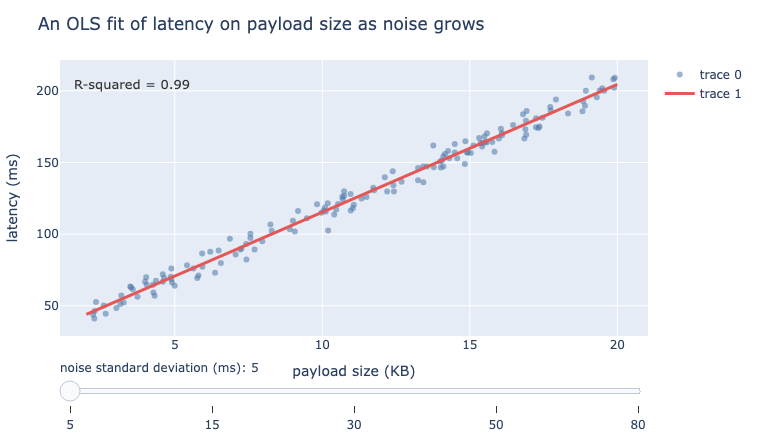

In [10]:
show(fig_ols_fit())

## Confidence intervals and prediction intervals

Latency (ms) against payload size (KB): the confidence band (red) narrows steadily as sample size grows, since a larger sample pins down the mean more precisely. The prediction band (blue) barely narrows at all, because no amount of data shrinks the irreducible variability of one new request.

In [11]:
def fig_ci_vs_pi() -> go.Figure:
    sample_sizes = [10, 25, 50, 150, 500]
    x_grid = np.linspace(2, 20, 60)
    frames = []
    for n in sample_sizes:
        x, y = payload_latency_sample(n, 30)
        slope, intercept, r, p, se = stats.linregress(x, y)
        y_hat = intercept + slope * x
        resid = y - y_hat
        s = np.sqrt(np.sum(resid ** 2) / (n - 2))
        x_bar = x.mean()
        sxx = np.sum((x - x_bar) ** 2)
        t_val = stats.t.ppf(0.975, df=n - 2)

        y_line = intercept + slope * x_grid
        se_mean = s * np.sqrt(1 / n + (x_grid - x_bar) ** 2 / sxx)
        se_pred = s * np.sqrt(1 + 1 / n + (x_grid - x_bar) ** 2 / sxx)
        ci_lo, ci_hi = y_line - t_val * se_mean, y_line + t_val * se_mean
        pi_lo, pi_hi = y_line - t_val * se_pred, y_line + t_val * se_pred

        frames.append(
            go.Frame(
                name=str(n),
                data=[
                    go.Scatter(x=np.concatenate([x_grid, x_grid[::-1]]),
                               y=np.concatenate([pi_hi, pi_lo[::-1]]),
                               fill="toself", fillcolor="rgba(76,120,168,0.15)",
                               line=dict(width=0), name="95% prediction interval"),
                    go.Scatter(x=np.concatenate([x_grid, x_grid[::-1]]),
                               y=np.concatenate([ci_hi, ci_lo[::-1]]),
                               fill="toself", fillcolor="rgba(228,87,86,0.35)",
                               line=dict(width=0), name="95% confidence interval"),
                    go.Scatter(x=x_grid, y=y_line, mode="lines",
                               line=dict(color="#333", width=2), name="fitted line"),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="The confidence interval narrows with sample size; the prediction interval "
              "barely does",
        xaxis_title="payload size (KB)",
        yaxis_title="latency (ms)",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "sample size (n): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

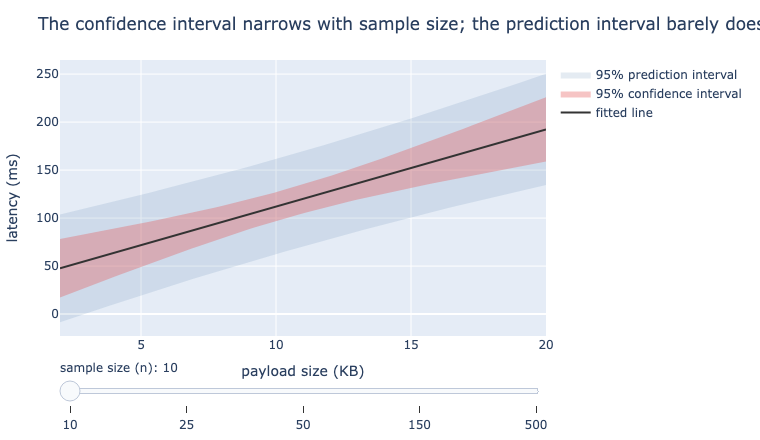

In [12]:
show(fig_ci_vs_pi())

## Logistic regression

P(timeout) against concurrent load: dots along the top and bottom edges are individual observed requests (timed out or not), and the S-shaped curve is the fitted probability. A steeper curve flips the service from healthy to overwhelmed over a narrower band of load; a shallower curve spreads that same transition across a wider range.

In [13]:
def fig_logistic_timeout() -> go.Figure:
    steepness_options = [0.05, 0.15, 0.3, 0.6, 1.0]
    load = np.linspace(0, 100, 300)
    midpoint = 60
    rng = np.random.default_rng(31)
    load_obs = rng.uniform(0, 100, 200)
    frames = []
    for k in steepness_options:
        p = 1 / (1 + np.exp(-k * (load - midpoint)))
        p_obs = 1 / (1 + np.exp(-k * (load_obs - midpoint)))
        outcome_obs = (rng.uniform(size=len(load_obs)) < p_obs).astype(float)
        frames.append(
            go.Frame(
                name=f"{k:.2f}",
                data=[
                    go.Scatter(x=load_obs, y=outcome_obs, mode="markers",
                               marker=dict(color="#72B7B2", size=6, opacity=0.5),
                               name="observed timeout (0/1)"),
                    go.Scatter(x=load, y=p, mode="lines",
                               line=dict(color="#E45756", width=3),
                               name="P(timeout)"),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Logistic regression: probability of a timeout as concurrent load rises",
        xaxis_title="concurrent load (%)",
        yaxis_title="P(timeout)",
        yaxis_range=[-0.05, 1.05],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "steepness of the logistic curve: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

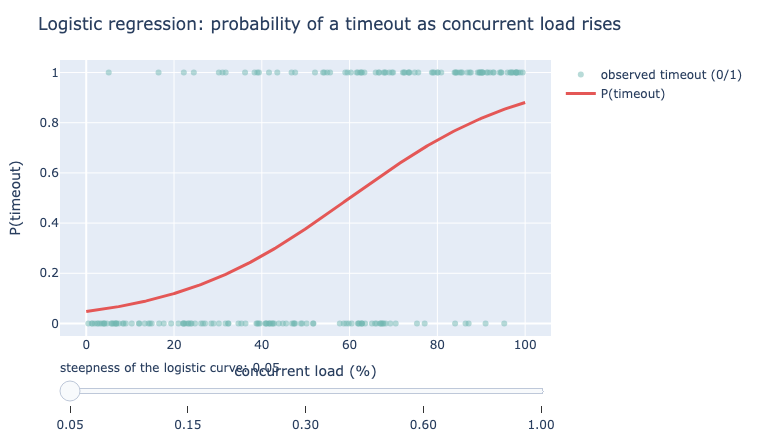

In [14]:
show(fig_logistic_timeout())

## Measuring fit: R-squared, adjusted R-squared, AIC, and BIC

Value (0 to 1) against the number of random noise predictors added to the model. R-squared (blue) always rises as predictors are added, even useless ones. Adjusted R-squared (red) penalizes that added complexity, flattening and then declining once the noise predictors stop paying for themselves.

In [15]:
def fig_r2_vs_adjusted() -> go.Figure:
    n = 40
    x, y = payload_latency_sample(n, 30, seed_offset=5)
    rng = np.random.default_rng(41)
    noise_predictors = rng.normal(size=(n, 20))

    max_k = list(range(0, 21))
    frames = []
    r2_series, adj_r2_series = [], []
    for k in max_k:
        X = np.column_stack([np.ones(n), x, noise_predictors[:, :k]])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        y_hat = X @ beta
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        p = X.shape[1] - 1
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
        r2_series.append(r2)
        adj_r2_series.append(adj_r2)
        frames.append(
            go.Frame(
                name=str(k),
                data=[
                    go.Scatter(x=max_k[: k + 1], y=r2_series, mode="lines+markers",
                               line=dict(color="#4C78A8", width=3), name="R-squared"),
                    go.Scatter(x=max_k[: k + 1], y=adj_r2_series, mode="lines+markers",
                               line=dict(color="#E45756", width=3), name="Adjusted R-squared"),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="R-squared always rises as predictors are added; adjusted R-squared does not",
        xaxis_title="number of random noise predictors added to the model",
        yaxis_title="value",
        xaxis_range=[0, 20],
        yaxis_range=[0, 1],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "noise predictors added: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

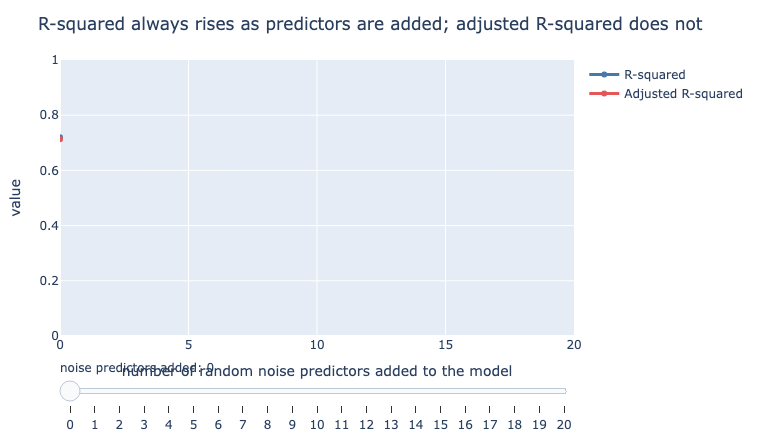

In [16]:
show(fig_r2_vs_adjusted())

## Measuring fit: R-squared, adjusted R-squared, AIC, and BIC

Both AIC and BIC reward adding region, which carries a measurable effect, but BIC penalizes the noise predictor, time of day, more heavily than AIC does, and that gap widens as the sample size grows.

In [17]:
def fig_aic_bic() -> go.Figure:
    rng = np.random.default_rng(61)
    n_max = 400
    payload = rng.uniform(2, 20, n_max)
    region = rng.normal(size=n_max)
    time_of_day = rng.normal(size=n_max)
    true_latency = 25 + 9 * payload + 6 * region + rng.normal(0, 20, n_max)

    model_specs = [
        ("payload only", [payload]),
        ("payload + region", [payload, region]),
        ("payload + region + time of day", [payload, region, time_of_day]),
    ]

    sample_sizes = [30, 60, 120, 250, 400]
    frames = []
    for n in sample_sizes:
        aic_vals, bic_vals = [], []
        y = true_latency[:n]
        for _, predictors in model_specs:
            X = np.column_stack([np.ones(n)] + [p[:n] for p in predictors])
            beta, *_ = np.linalg.lstsq(X, y, rcond=None)
            resid = y - X @ beta
            k = X.shape[1]
            sigma2 = np.sum(resid ** 2) / n
            log_lik = -0.5 * n * (np.log(2 * np.pi * sigma2) + 1)
            aic_vals.append(-2 * log_lik + 2 * k)
            bic_vals.append(-2 * log_lik + k * np.log(n))

        labels = [name for name, _ in model_specs]
        frames.append(
            go.Frame(
                name=str(n),
                data=[
                    go.Bar(x=labels, y=aic_vals, name="AIC", marker_color="#4C78A8"),
                    go.Bar(x=labels, y=bic_vals, name="BIC", marker_color="#E45756"),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        barmode="group",
        title="AIC and BIC across three candidate models, as sample size grows",
        yaxis_title="information criterion (lower is better)",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "sample size (n): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

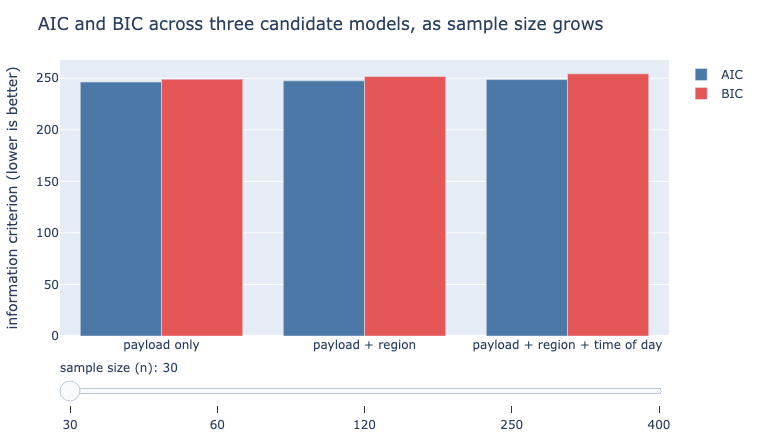

In [18]:
show(fig_aic_bic())

## Model interpretation: statistical significance versus practical significance

The estimated effect (0.1 ms) never moves. Only its 95% confidence interval does: wide and straddling zero at small sample sizes, narrow and clear of zero once the sample is large enough. The marker turns red the moment the p-value crosses 0.05, at a sample size where 0.1 ms is still too small to act on.

In [19]:
def fig_significance_vs_sample_size() -> go.Figure:
    true_effect = 0.1  # ms: the same tiny, practically negligible effect used in the text
    noise_sd = 30.0    # ms: same latency noise scale used throughout this chapter's figures

    sample_sizes = [1_000, 10_000, 100_000, 500_000, 2_000_000, 10_000_000]
    frames = []
    for n in sample_sizes:
        # The point estimate is held at the true effect on purpose, rather than redrawn
        # per frame: the story here is that the effect size itself never moves. Only the
        # standard error, se = noise_sd / sqrt(n), shrinks as n grows, which is what pulls
        # the confidence interval away from zero and the p-value below 0.05.
        se = noise_sd / np.sqrt(n)
        z = true_effect / se
        p_value = 2 * (1 - stats.norm.cdf(abs(z)))
        ci_lo, ci_hi = true_effect - 1.96 * se, true_effect + 1.96 * se
        significant = p_value < 0.05

        frames.append(
            go.Frame(
                name=str(n),
                data=[
                    go.Scatter(
                        x=[true_effect], y=[0], mode="markers",
                        marker=dict(size=18, color="#E45756" if significant else "#4C78A8"),
                        error_x=dict(type="data", array=[1.96 * se], visible=True,
                                     thickness=3, width=10,
                                     color="#E45756" if significant else "#4C78A8"),
                        name="estimated effect",
                    ),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.02, y=0.85, xref="paper", yref="paper", showarrow=False, align="left",
                    text=(f"n = {n:,}<br>"
                          f"estimated effect = {true_effect:.3f} ms<br>"
                          f"95% CI = [{ci_lo:.3f}, {ci_hi:.3f}]<br>"
                          f"p-value = {p_value:.4g}<br>"
                          + ("statistically significant" if significant
                             else "not statistically significant") + " at alpha = 0.05"),
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="A fixed 0.1 ms effect crosses statistical significance as sample size grows",
        xaxis_title="estimated effect on latency (ms)",
        xaxis_range=[-2, 2.3],
        yaxis=dict(visible=False, range=[-1, 1]),
        shapes=[dict(type="line", x0=0, x1=0, y0=-1, y1=1,
                     line=dict(color="#999", width=1, dash="dot"))],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "sample size (n): "},
            "steps": [
                {"label": _short_n(int(f.name)), "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

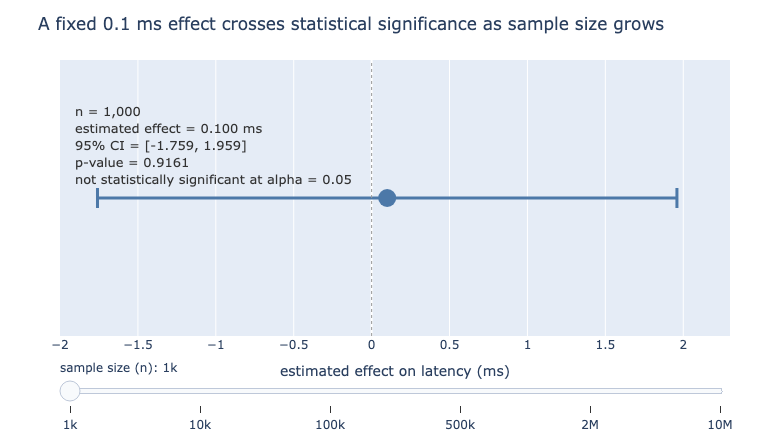

In [20]:
show(fig_significance_vs_sample_size())

## Regularization: Lasso, Ridge, and Elastic Net

Coefficient value for each predictor, comparing Lasso (red) against Ridge (blue) as the regularization strength grows. As regularization strengthens, Lasso zeroes out the noise predictor and one of the two correlated region indicators, while Ridge only shrinks every coefficient toward zero without eliminating any of them.

In [21]:
def fig_regularization_paths() -> go.Figure:
    n = 60
    rng = np.random.default_rng(51)
    payload = rng.uniform(2, 20, n)
    region_a = rng.normal(size=n) * 0.5 + payload * 0.3   # correlated with payload
    region_b = rng.normal(size=n) * 0.5 + payload * 0.25  # also correlated with payload
    time_of_day = rng.normal(size=n)                       # unrelated noise feature
    endpoint_flag = rng.normal(size=n) * 0.3 + payload * 0.1

    X_raw = np.column_stack([payload, region_a, region_b, time_of_day, endpoint_flag])
    X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
    true_beta = np.array([9.0, 3.0, 2.5, 0.0, 1.0])
    y = X_raw @ true_beta + rng.normal(0, 15, size=n)
    y = y - y.mean()

    # lambdas run from 0.01 to 40 rather than 60: at the old top end (60) the Lasso
    # threshold, scaled to match this standardized design matrix, zeroed out every
    # predictor except payload size, including region A, so the chart no longer showed
    # the "keeps one of the two correlated region indicators" behavior the caption
    # describes. The 10x scale factor below (lam * 10) brings Lasso's zeroing point into
    # the same lambda range where Ridge's shrinkage is also visible, so both traces move
    # meaningfully across the same slider instead of Lasso barely changing at all.
    lambdas = [0.01, 0.5, 2, 8, 25, 40]
    feature_names = ["payload size", "region A", "region B", "time of day", "endpoint"]

    frames = []
    for lam in lambdas:
        lasso_beta = lasso_coordinate_descent(X, y, lam=lam * 10)
        ridge_beta = ridge_closed_form(X, y, lam=lam)
        frames.append(
            go.Frame(
                name=f"{lam:g}",
                data=[
                    go.Bar(x=feature_names, y=lasso_beta, name="Lasso", marker_color="#E45756"),
                    go.Bar(x=feature_names, y=ridge_beta, name="Ridge", marker_color="#4C78A8"),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        barmode="group",
        title="Lasso drives correlated and irrelevant coefficients to zero; "
              "Ridge only shrinks them",
        yaxis_title="coefficient value",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "regularization strength (lambda): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=70, l=60, r=30, b=50),
    )
    return fig

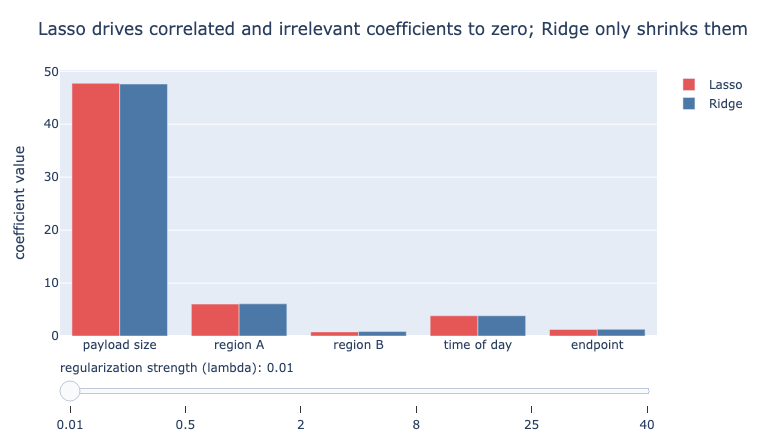

In [22]:
show(fig_regularization_paths())

## A Bayesian perspective

As the prior variance shrinks, equivalent to $\lambda$ growing, the posterior on the payload-size coefficient narrows and its center moves toward zero, tracing the same shrinkage Ridge regression's penalty term produces.

In [23]:
def fig_bayesian_ridge() -> go.Figure:
    x, y = payload_latency_sample(150, 30, seed_offset=9)
    x_c = x - x.mean()
    y_c = y - y.mean()
    slope, intercept, r, p, se = stats.linregress(x, y)
    resid = y_c - slope * x_c
    sigma2 = np.sum(resid ** 2) / (len(x) - 2)
    S = np.sum(x_c ** 2)
    b = np.sum(x_c * y_c)

    prior_variances = [1e6, 50, 10, 3, 1, 0.3]
    beta_grid = np.linspace(-2, 16, 400)
    frames = []
    for tau2 in prior_variances:
        precision = S / sigma2 + 1 / tau2
        post_mean = (b / sigma2) / precision
        post_sd = np.sqrt(1 / precision)
        implied_lambda = sigma2 / tau2
        density = stats.norm.pdf(beta_grid, loc=post_mean, scale=post_sd)
        frames.append(
            go.Frame(
                name=f"{tau2:g}",
                data=[
                    go.Scatter(x=beta_grid, y=density, mode="lines",
                               line=dict(color="#4C78A8", width=3), fill="tozeroy",
                               fillcolor="rgba(76,120,168,0.2)", name="posterior"),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.02, y=0.95, xref="paper", yref="paper", showarrow=False,
                    align="left",
                    text=(f"posterior mean = {post_mean:.2f}<br>"
                          f"posterior sd = {post_sd:.2f}<br>"
                          f"implied Ridge λ = {implied_lambda:.2f}"),
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="A tighter Gaussian prior on the slope is Ridge regression: the posterior "
              "narrows and shrinks toward zero",
        xaxis_title="coefficient on payload size (beta)",
        yaxis_title="posterior density",
        xaxis_range=[-2, 16],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "prior variance on beta (tau-squared): "},
            # y and pad.t push the slider well clear of the x-axis title below it,
            # which otherwise renders in the same vertical band and overlaps the
            # slider's "currentvalue" caption text.
            "y": -0.32,
            "pad": {"t": 40},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=120),
    )
    return fig

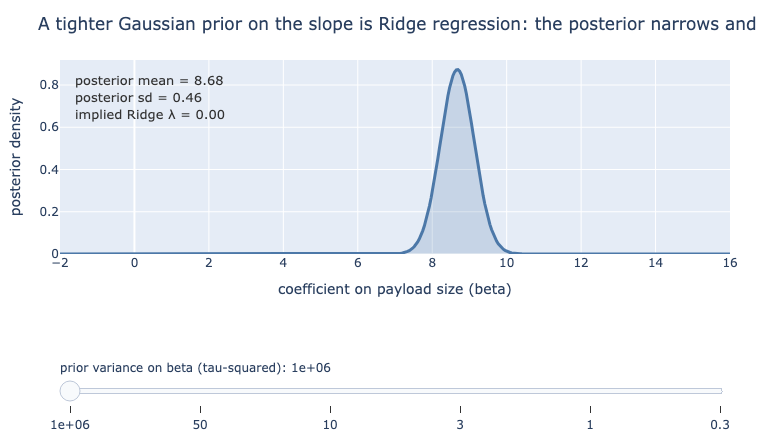

In [24]:
show(fig_bayesian_ridge())